TP — DEEP LEARNING -
Deep Residual Learning for Image Recognition.



nom : Ait baha Mohamed  

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
import os


In [ ]:

# ============================================================
# 1. CONFIGURATION
# ============================================================
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED = 42
EPOCHS = 5          # Mettre 60 pour reproduire l'article (GPU recommandé)
BATCH_SIZE = 128
LR = 0.1
OUTPUT_DIR = 'outputs'

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Reproductibilité
torch.manual_seed(SEED)
np.random.seed(SEED)
if DEVICE == 'cuda':
    torch.cuda.manual_seed_all(SEED)

print(f'Device : {DEVICE}')
print(f'PyTorch : {torch.__version__}')
print(f'Torchvision : {torchvision.__version__}')
print(f'NumPy : {np.__version__}')


Device : cuda
PyTorch : 2.11.0+cu128
Torchvision : 0.26.0+cu128
NumPy : 2.1.3


In [ ]:

# ============================================================
# 2. DÉFINITION DES BLOCS
# ============================================================

class BasicBlock(nn.Module):
    """
    Bloc résiduel à 2 couches 3×3 (option A : identité + zero-padding).
    Formulation : y = F(x) + x
    """
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self._pad = (stride != 1 or in_planes != planes)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        if self._pad:
            sc = F.avg_pool2d(x, kernel_size=2, stride=2) \
                 if x.shape[-1] != out.shape[-1] else x
            pad = out.shape[1] - sc.shape[1]
            if pad > 0:
                sc = F.pad(sc, (0, 0, 0, 0, 0, pad))
        else:
            sc = x

        out = out + sc           # ← shortcut connection
        return F.relu(out)


class PlainBlock(nn.Module):
    """Bloc plain (sans shortcut)."""
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.relu(out)       # ← pas de + x !


In [ ]:

# ============================================================
# 3. ARCHITECTURE CIFAR-10
# ============================================================

class CifarNet(nn.Module):
    """
    Architecture CIFAR-10 de l'article (section 4.2).
    Profondeur = 6n + 2.
    """
    def __init__(self, block, n=3, num_classes=10):
        super().__init__()
        self.in_planes = 16

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)

        self.layer1 = self._make_layer(block, 16, n, stride=1)  # 32×32
        self.layer2 = self._make_layer(block, 32, n, stride=2)  # 16×16
        self.layer3 = self._make_layer(block, 64, n, stride=2)  # 8×8

        self.fc = nn.Linear(64, num_classes)

    def _make_layer(self, block, planes, n, stride):
        layers = []
        for s in [stride] + [1] * (n - 1):
            layers.append(block(self.in_planes, planes, s))
            self.in_planes = planes
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = F.avg_pool2d(out, out.shape[-1])
        out = out.view(out.size(0), -1)
        return self.fc(out)



In [ ]:

# ============================================================
# 4. CHARGEMENT DE CIFAR-10
# ============================================================

def get_cifar10_loaders(batch_size=128):
    mean = (0.4914, 0.4822, 0.4465)
    std  = (0.2470, 0.2435, 0.2616)

    train_tf = T.Compose([
        T.RandomCrop(32, padding=4),
        T.RandomHorizontalFlip(),
        T.ToTensor(),
        T.Normalize(mean, std),
    ])
    test_tf = T.Compose([
        T.ToTensor(),
        T.Normalize(mean, std),
    ])

    train_ds = torchvision.datasets.CIFAR10(
        './data', train=True, download=True, transform=train_tf)
    test_ds = torchvision.datasets.CIFAR10(
        './data', train=False, download=True, transform=test_tf)

    train_loader = torch.utils.data.DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=2, pin_memory=True)
    test_loader = torch.utils.data.DataLoader(
        test_ds, batch_size=256, shuffle=False,
        num_workers=2, pin_memory=True)

    return train_loader, test_loader



In [ ]:

# ============================================================
# 5. ENTRAÎNEMENT ET ÉVALUATION
# ============================================================

@torch.no_grad()
def evaluate(model, loader, device='cpu'):
    """Calcule l'erreur de test (en %)."""
    model.eval()
    total, correct = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        correct += (out.argmax(1) == y).sum().item()
        total += x.size(0)
    return 100.0 * (1 - correct / total)


def train(model, loader, epochs=10, lr=0.1, device='cpu', verbose=True):
    """Entraîne le modèle et retourne l'historique."""
    model.to(device)
    opt = torch.optim.SGD(model.parameters(), lr=lr,
                          momentum=0.9, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.MultiStepLR(
        opt, milestones=[int(epochs * 0.5), int(epochs * 0.75)], gamma=0.1)
    crit = nn.CrossEntropyLoss()
    hist = {'train_err': [], 'test_err': [], 'loss': []}

    for ep in range(epochs):
        model.train()
        total, correct, loss_sum = 0, 0, 0.0
        t0 = time.time()

        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            out = model(x)
            loss = crit(out, y)
            loss.backward()
            opt.step()

            loss_sum += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)

        train_err = 100.0 * (1 - correct / total)
        test_err = evaluate(model, loader, device)  # placeholder, remplacé après
        hist['train_err'].append(train_err)
        hist['loss'].append(loss_sum / total)
        sched.step()

        if verbose:
            dt = time.time() - t0
            print(f'Epoch {ep+1:2d}/{epochs} | loss {loss_sum/total:.3f} | '
                  f'train_err {train_err:5.2f}% | {dt:.1f}s')

    return hist


def train_full(model, train_loader, test_loader, epochs=10, lr=0.1, device='cpu'):
    """Entraîne et évalue à chaque epoch sur le test set."""
    model.to(device)
    opt = torch.optim.SGD(model.parameters(), lr=lr,
                          momentum=0.9, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.MultiStepLR(
        opt, milestones=[int(epochs * 0.5), int(epochs * 0.75)], gamma=0.1)
    crit = nn.CrossEntropyLoss()
    hist = {'train_err': [], 'test_err': [], 'loss': []}

    for ep in range(epochs):
        model.train()
        total, correct, loss_sum = 0, 0, 0.0
        t0 = time.time()

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            out = model(x)
            loss = crit(out, y)
            loss.backward()
            opt.step()

            loss_sum += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)

        train_err = 100.0 * (1 - correct / total)
        test_err = evaluate(model, test_loader, device)
        hist['train_err'].append(train_err)
        hist['test_err'].append(test_err)
        hist['loss'].append(loss_sum / total)
        sched.step()

        dt = time.time() - t0
        print(f'Epoch {ep+1:2d}/{epochs} | loss {loss_sum/total:.3f} | '
              f'train_err {train_err:5.2f}% | test_err {test_err:5.2f}% | {dt:.1f}s')

    return hist


In [ ]:

# ============================================================
# 6. EXPÉRIENCE : PLAIN vs RESNET
# ============================================================

def run_experiments():
    print('\n' + '=' * 60)
    print('CHARGEMENT DE CIFAR-10')
    print('=' * 60)
    train_loader, test_loader = get_cifar10_loaders(BATCH_SIZE)
    print(f'Train : {len(train_loader.dataset)} images')
    print(f'Test  : {len(test_loader.dataset)} images')

    experiments = [
        ('Plain-20',  PlainBlock, 3),
        ('Plain-56',  PlainBlock, 9),
        ('ResNet-20', BasicBlock, 3),
        ('ResNet-56', BasicBlock, 9),
    ]

    results = {}
    print('\n' + '=' * 60)
    print('ENTRAÎNEMENT')
    print('=' * 60)

    for name, block, n in experiments:
        print(f'\n--- {name} (profondeur = {6*n+2}) ---')
        model = CifarNet(block, n=n)
        n_params = sum(p.numel() for p in model.parameters())
        print(f'Paramètres : {n_params:,}')

        hist = train_full(model, train_loader, test_loader,
                          epochs=EPOCHS, lr=LR, device=DEVICE)
        results[name] = hist

        torch.save(model.state_dict(), f'{OUTPUT_DIR}/{name}.pt')

    # Tableau récapitulatif
    print('\n' + '=' * 60)
    print('RÉSULTATS FINAUX')
    print('=' * 60)
    print(f"| {'Modèle':<11} | {'Train Err.':<10} | {'Test Err.':<10} |")
    print(f"|{'-'*13}|{'-'*12}|{'-'*12}|")
    for name in ['Plain-20', 'Plain-56', 'ResNet-20', 'ResNet-56']:
        h = results[name]
        print(f"| {name:<11} | {h['train_err'][-1]:>8.2f}%  | {h['test_err'][-1]:>8.2f}%  |")

    return results, train_loader, test_loader

In [ ]:

# ============================================================
# 7. FIGURE 1 : PLAIN vs RESNET
# ============================================================

def plot_plain_vs_resnet(results):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    colors = {'20': 'tab:blue', '56': 'tab:red'}

    for ax, family in zip(axes, ['Plain', 'ResNet']):
        for depth in ['20', '56']:
            key = f'{family}-{depth}'
            h = results[key]
            ep = np.arange(1, len(h['train_err']) + 1)
            ax.plot(ep, h['train_err'], '--', color=colors[depth],
                    alpha=0.6, label=f'{key} (train)')
            ax.plot(ep, h['test_err'], '-', color=colors[depth],
                    linewidth=2.2, label=f'{key} (test)')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Erreur (%)')
        ax.set_title(f'{family} networks', fontsize=13, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)

    plt.suptitle('Comparaison Plain vs ResNet — CIFAR-10',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/fig1_plain_vs_resnet.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figure sauvegardée : {OUTPUT_DIR}/fig1_plain_vs_resnet.png')


In [ ]:


# ============================================================
# 8. FIGURE 7 : ANALYSE DES RÉPONSES DE COUCHES
# ============================================================

@torch.no_grad()
def layer_response_stds(model, x, device='cpu'):
    """Récupère les std des sorties de chaque conv 3×3 (après BN, avant ReLU)."""
    model.eval()
    model.to(device)
    stds = []
    hooks = []

    def hook(module, inp, out):
        stds.append(out.std().item())

    for m in model.modules():
        if isinstance(m, nn.Conv2d) and m.kernel_size == (3, 3):
            hooks.append(m.register_forward_hook(hook))

    _ = model(x.to(device))
    for h in hooks:
        h.remove()
    return np.array(stds)


def plot_layer_responses(experiments, test_loader):
    # Récupérer un batch de test
    xb, _ = next(iter(test_loader))
    xb = xb[:64]

    # Calculer les stds
    responses = {}
    for name, block, n in experiments:
        m = CifarNet(block, n=n)
        m.load_state_dict(torch.load(f'{OUTPUT_DIR}/{name}.pt',
                                     map_location=DEVICE))
        responses[name] = layer_response_stds(m, xb, DEVICE)
        print(f'{name:<10} : {len(responses[name])} couches 3×3')

    # Tracé
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    styles = {
        'Plain-20':  ('tab:blue',   'o'),
        'Plain-56':  ('tab:orange', 's'),
        'ResNet-20': ('tab:green',  '^'),
        'ResNet-56': ('tab:red',    'v'),
    }

    for name, (color, marker) in styles.items():
        s = responses[name]
        axes[0].plot(range(1, len(s) + 1), s, marker=marker, ms=3,
                     color=color, label=name)
        axes[1].plot(range(1, len(s) + 1), np.sort(s)[::-1],
                     marker=marker, ms=3, color=color, label=name)

    for ax, title in zip(axes, ['Ordre original', 'Trié décroissant']):
        ax.set_xlabel('Index de couche')
        ax.set_ylabel('Std de la réponse')
        ax.set_title(title)
        ax.legend()
        ax.grid(alpha=0.3)

    plt.suptitle("Analyse des réponses de couches (Figure 7 de l'article)",
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/fig7_layer_responses.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figure sauvegardée : {OUTPUT_DIR}/fig7_layer_responses.png')




CHARGEMENT DE CIFAR-10
Train : 50000 images
Test  : 10000 images

ENTRAÎNEMENT

--- Plain-20 (profondeur = 20) ---
Paramètres : 269,722
Epoch  1/5 | loss 1.790 | train_err 68.59% | test_err 65.56% | 24.0s
Epoch  2/5 | loss 1.520 | train_err 56.83% | test_err 54.41% | 23.8s
Epoch  3/5 | loss 1.235 | train_err 44.94% | test_err 43.17% | 23.1s
Epoch  4/5 | loss 1.179 | train_err 42.86% | test_err 41.42% | 23.6s
Epoch  5/5 | loss 1.165 | train_err 42.19% | test_err 41.08% | 24.0s

--- Plain-56 (profondeur = 56) ---
Paramètres : 853,018
Epoch  1/5 | loss 2.230 | train_err 85.42% | test_err 82.47% | 45.6s
Epoch  2/5 | loss 2.018 | train_err 77.17% | test_err 76.10% | 45.3s
Epoch  3/5 | loss 1.919 | train_err 73.85% | test_err 70.81% | 45.4s
Epoch  4/5 | loss 1.895 | train_err 72.29% | test_err 69.61% | 45.6s
Epoch  5/5 | loss 1.895 | train_err 71.88% | test_err 69.53% | 45.5s

--- ResNet-20 (profondeur = 20) ---
Paramètres : 269,722
Epoch  1/5 | loss 1.658 | train_err 62.63% | test_err 54.0

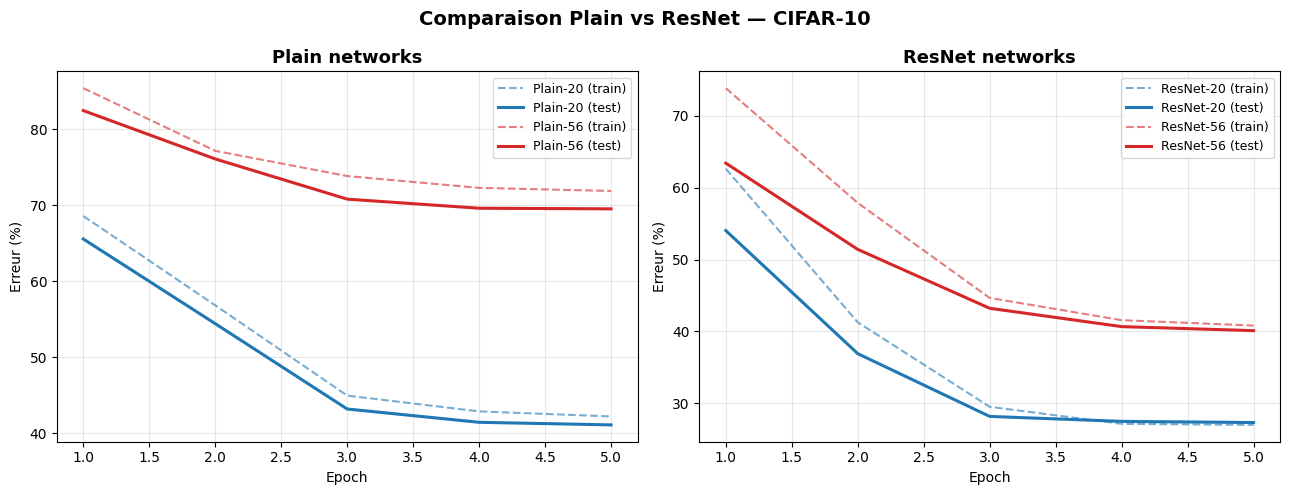

Figure sauvegardée : outputs/fig1_plain_vs_resnet.png
Plain-20   : 19 couches 3×3
Plain-56   : 55 couches 3×3
ResNet-20  : 19 couches 3×3
ResNet-56  : 55 couches 3×3


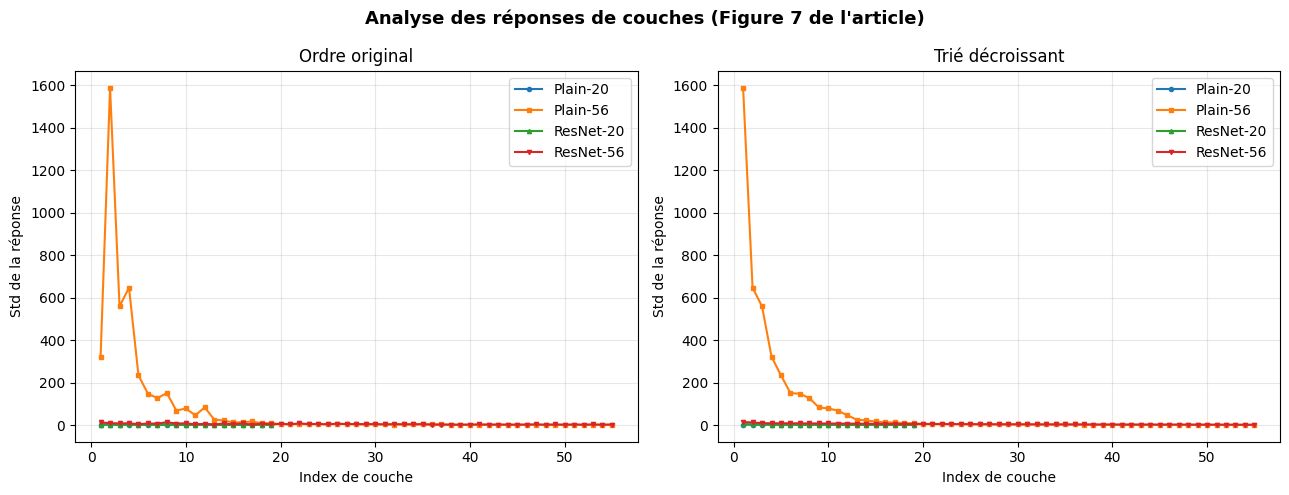

Figure sauvegardée : outputs/fig7_layer_responses.png

TERMINÉ
Figures générées :
  - outputs/fig1_plain_vs_resnet.png
  - outputs/fig7_layer_responses.png
Modèles sauvegardés :
  - outputs/Plain-20.pt
  - outputs/Plain-56.pt
  - outputs/ResNet-20.pt
  - outputs/ResNet-56.pt


In [ ]:

# ============================================================
# 9. MAIN
# ============================================================

def main():
    # Expériences principales
    results, train_loader, test_loader = run_experiments()

    # Figures
    print('\n' + '=' * 60)
    print('GÉNÉRATION DES FIGURES')
    print('=' * 60)
    plot_plain_vs_resnet(results)

    experiments = [
        ('Plain-20',  PlainBlock, 3),
        ('Plain-56',  PlainBlock, 9),
        ('ResNet-20', BasicBlock, 3),
        ('ResNet-56', BasicBlock, 9),
    ]
    plot_layer_responses(experiments, test_loader)

    # Résumé final
    print('\n' + '=' * 60)
    print('TERMINÉ')
    print('=' * 60)
    print('Figures générées :')
    print(f'  - {OUTPUT_DIR}/fig1_plain_vs_resnet.png')
    print(f'  - {OUTPUT_DIR}/fig7_layer_responses.png')
    print('Modèles sauvegardés :')
    for name in ['Plain-20', 'Plain-56', 'ResNet-20', 'ResNet-56']:
        print(f'  - {OUTPUT_DIR}/{name}.pt')


if __name__ == '__main__':
    main()